# Qiskit Fall Fest 2026 — Challenge 4: Quantum Correlation Switch
**IBM Quantum | Vishnu Institute of Technology**

## Objective
Build two two-qubit circuits: Part A gives correlated outcomes (`00` and `11`) and Part B gives opposite outcomes (`01` and `10`). Run each for 100 shots, plot histograms, compare them, and explain why the relationship changes.

**Design constraints met:** exactly 2 qubits, both qubits measured, at most 4 gates before measurement (Part A uses 2, Part B uses 3), only the H, CNOT and X gates from the workshop, Qiskit only, 100 shots per experiment.

## 1. Setup
Install Qiskit and the simulator if needed.

In [1]:
%pip install -q qiskit qiskit-aer matplotlib pylatexenc

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

SHOTS = 100
OUTCOMES = ['00', '01', '10', '11']
simulator = AerSimulator()


def run_circuit(qc, shots=SHOTS):
    """Run a circuit on the simulator and return the measurement counts."""
    compiled = transpile(qc, simulator)
    return simulator.run(compiled, shots=shots).result().get_counts()


def summarize(label, counts):
    """Print all four outcome counts and how often the two bits matched."""
    total = sum(counts.values())
    same = counts.get('00', 0) + counts.get('11', 0)
    diff = counts.get('01', 0) + counts.get('10', 0)
    parts = ', '.join(f'{o}={counts.get(o, 0)}' for o in OUTCOMES)
    print(f'{label}: {parts}  |  same bits: {same} ({same/total:.0%}), '
          f'different bits: {diff} ({diff/total:.0%})')


print(f'Setup complete: {SHOTS} shots per circuit.')

Setup complete: 100 shots per circuit.


## 2. Predictions before running

| | Part A (H, CNOT) | Part B (H, CNOT, X on qubit 1) |
|---|---|---|
| Dominant outcomes | `00` and `11` | `01` and `10` |
| Expected split | about 50 each | about 50 each |
| Outcomes that should not appear | `01`, `10` | `00`, `11` |
| Do all four outcomes appear? | No, only two | No, only two |

**Why are some outcomes much more frequent than others?** The two qubits are entangled, so they cannot be measured independently. The state only has amplitude on two of the four basis states, and the other two have zero probability. Which two are allowed depends on the gates. The two allowed outcomes are each about 50% likely, but 100 shots will not split exactly 50/50.

## 3. Part A — Correlated outcomes

**Circuit:** an H gate on qubit 0 puts it in an equal superposition, then a CNOT (control qubit 0, target qubit 1) copies that result onto qubit 1. This creates the Bell state (|00⟩ + |11⟩)/√2. The circuit has 2 gates before measurement.

Part A — correlated circuit:


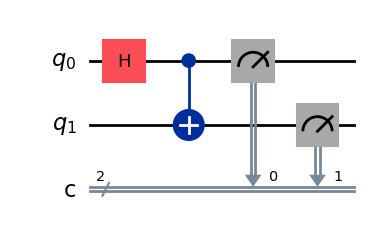

In [3]:
circuit_a = QuantumCircuit(2, 2)
circuit_a.h(0)
circuit_a.cx(0, 1)
circuit_a.measure([0, 1], [0, 1])

print('Part A — correlated circuit:')
display(circuit_a.draw('mpl'))

Part A counts: {'11': 54, '00': 46}


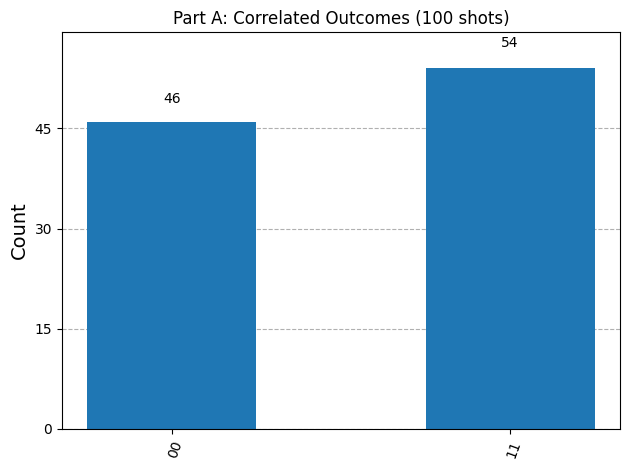

In [4]:
counts_a = run_circuit(circuit_a)
print('Part A counts:', counts_a)
display(plot_histogram(counts_a, title='Part A: Correlated Outcomes (100 shots)'))

## 4. Part B — Opposite outcomes

**Modification:** add one X gate on qubit 1, after the CNOT and before measurement. The circuit has 3 gates before measurement. The X gate flips qubit 1, which turns the state into (|01⟩ + |10⟩)/√2.

*Reading the labels:* Qiskit prints qubit 1 on the left and qubit 0 on the right. `01` and `10` are the two outcomes where the bits differ.

Part B — opposite-outcome circuit:


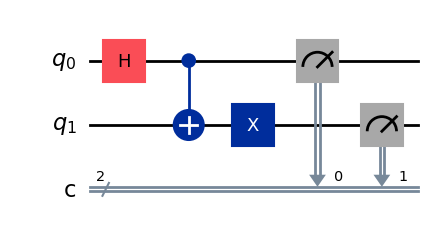

In [5]:
circuit_b = QuantumCircuit(2, 2)
circuit_b.h(0)
circuit_b.cx(0, 1)
circuit_b.x(1)  # The switch: flip qubit 1
circuit_b.measure([0, 1], [0, 1])

print('Part B — opposite-outcome circuit:')
display(circuit_b.draw('mpl'))

Part B counts: {'01': 54, '10': 46}


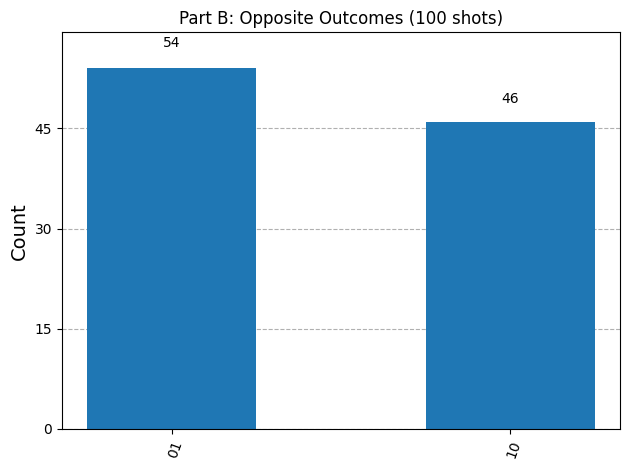

In [6]:
counts_b = run_circuit(circuit_b)
print('Part B counts:', counts_b)
display(plot_histogram(counts_b, title='Part B: Opposite Outcomes (100 shots)'))

## 5. Part C — Compare the results

Outcome         Part A    Part B
--------------------------------
00                  46         0
01                   0        54
10                   0        46
11                  54         0

Part A: 00=46, 01=0, 10=0, 11=54  |  same bits: 100 (100%), different bits: 0 (0%)
Part B: 00=0, 01=54, 10=46, 11=0  |  same bits: 0 (0%), different bits: 100 (100%)


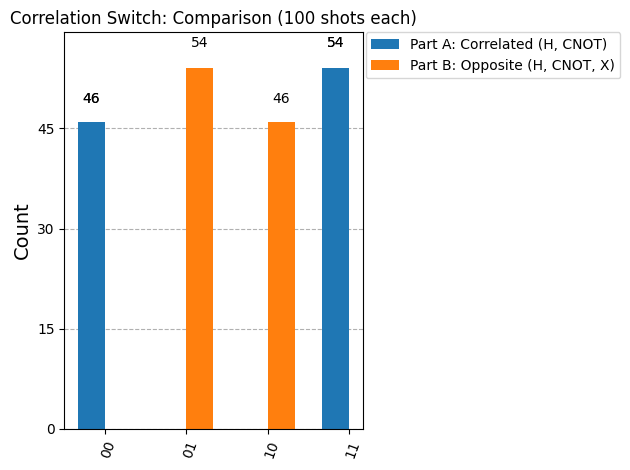

In [7]:
print(f'{"Outcome":<12}{"Part A":>10}{"Part B":>10}')
print('-' * 32)
for outcome in OUTCOMES:
    print(f'{outcome:<12}{counts_a.get(outcome, 0):>10}{counts_b.get(outcome, 0):>10}')
print()
summarize('Part A', counts_a)
summarize('Part B', counts_b)

display(plot_histogram(
    [counts_a, counts_b],
    legend=['Part A: Correlated (H, CNOT)', 'Part B: Opposite (H, CNOT, X)'],
    title='Correlation Switch: Comparison (100 shots each)'
))

## 6. Predictions vs observed results

In [8]:
a_main = counts_a.get('00', 0) + counts_a.get('11', 0)
b_main = counts_b.get('01', 0) + counts_b.get('10', 0)
a_outcomes = [o for o in OUTCOMES if counts_a.get(o, 0) > 0]
b_outcomes = [o for o in OUTCOMES if counts_b.get(o, 0) > 0]

print(f'Part A: {a_main}/{SHOTS} shots were 00 or 11 (predicted: all {SHOTS}). Outcomes seen: {a_outcomes}')
print(f'Part A: 00 = {counts_a.get("00", 0)}, 11 = {counts_a.get("11", 0)} (predicted: about 50 each).')
print(f'Part B: {b_main}/{SHOTS} shots were 01 or 10 (predicted: all {SHOTS}). Outcomes seen: {b_outcomes}')
print(f'Part B: 01 = {counts_b.get("01", 0)}, 10 = {counts_b.get("10", 0)} (predicted: about 50 each).')
print('Only two of the four outcomes appeared in each circuit:', len(a_outcomes) == 2 and len(b_outcomes) == 2)
print('All predictions confirmed:', a_main == SHOTS and b_main == SHOTS)

Part A: 100/100 shots were 00 or 11 (predicted: all 100). Outcomes seen: ['00', '11']
Part A: 00 = 46, 11 = 54 (predicted: about 50 each).
Part B: 100/100 shots were 01 or 10 (predicted: all 100). Outcomes seen: ['01', '10']
Part B: 01 = 54, 10 = 46 (predicted: about 50 each).
Only two of the four outcomes appeared in each circuit: True
All predictions confirmed: True


## 7. Explanation

- **Which outcomes dominate in Part A?** `00` and `11`, about half each. The two bits always match.
- **Which outcomes dominate in Part B?** `01` and `10`, about half each. The two bits are always opposite.
- **What changed between the two circuits?** Only one X gate was added, on qubit 1 just before measurement.
- **Why did the measurement relationship change?** In Part A, the H gate makes qubit 0 a 50/50 superposition and the CNOT ties qubit 1 to it, giving (|00⟩ + |11⟩)/√2. In Part B, the X gate swaps `|0⟩` and `|1⟩` on qubit 1 in every term, turning |00⟩ into |01⟩ and |11⟩ into |10⟩. The state becomes (|01⟩ + |10⟩)/√2, so the matching pairs become opposite pairs.
- **Why do only two outcomes appear?** The qubits are entangled, so the result of one measurement fixes the other. Each individual qubit is still a fair coin flip, but together they only produce the two allowed combinations. With 100 shots the split is close to, but not exactly, 50/50.

## 8. Conclusion

The Bell-state circuit (H, CNOT) produces correlated results, `00` and `11`. Adding one X gate on qubit 1 switches the results to opposite outcomes, `01` and `10`. Both circuits use exactly two qubits, measure both qubits, use at most three gates before measurement, and run for 100 shots.